# Caderno de teste e modelagem para visão computacional

Este notebook pode ser utilizado como ponto de partida para conhecimento das bibliotecas YOLO e supervision, oportunas soluções que oferecem classes métodos bem documentados para operações de visão computacional genérica e para ações de segmentação e apresentação das inferências. 

As referências utilizadas para a construção das seções aqui apresentadas, são:
- https://github.com/roboflow/supervision
- https://supervision.roboflow.com/latest/detection/annotators/
- https://supervision.roboflow.com/latest/keypoint/annotators/
- https://pjreddie.com/darknet/yolo/
- https://github.com/ultralytics/ultralytics?tab=readme-ov-file
- https://docs.ultralytics.com/guides/isolating-segmentation-objects/

Sobre HOG (Histograms of Oriented Gradients)
- https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html
- https://thepythoncode.com/article/hog-feature-extraction-in-python
- https://www.kaggle.com/code/brendan45774/hog-features-histogram-of-oriented-gradients
- https://thedatafrog.com/en/articles/human-detection-video/



Instalação das bibliotecas com o instalador de pacotes para o Python, `pip`

In [ ]:
!pip install -r requirements.txt

In [1]:
import cv2
import supervision as sv
from ultralytics import YOLO

In [3]:
image = cv2.imread("../2carasMoto2.jpg")
image_key = cv2.imread("../2carasMoto2.jpg")

model = YOLO('yolov8s.pt')

result = model(image)[0]

detections = sv.Detections.from_ultralytics(result)


0: 576x640 2 persons, 5 cars, 2 motorcycles, 1 truck, 373.1ms
Speed: 2.6ms preprocess, 373.1ms inference, 1.1ms postprocess per image at shape (1, 3, 576, 640)


In [4]:
len(detections)

10

In [5]:
bounding_box_annotator = sv.BoundingBoxAnnotator()
annotated_frame = bounding_box_annotator.annotate(
    scene=image.copy(),
    detections=detections
)

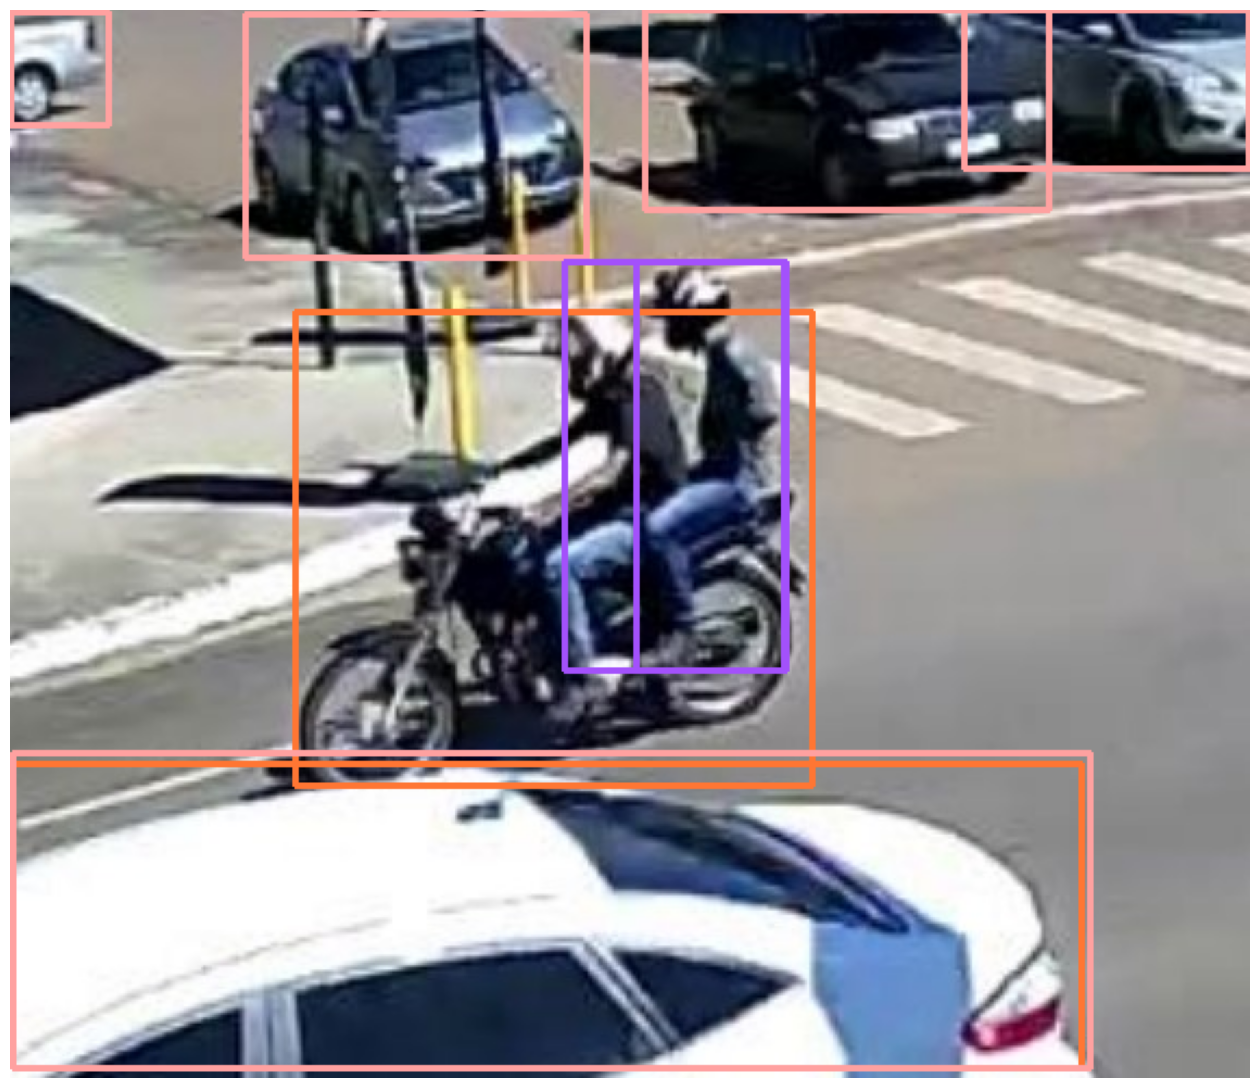

In [6]:
sv.plot_image(annotated_frame, (16, 16))

In [7]:
corner_annotator = sv.BoxCornerAnnotator()
annotated_frame = corner_annotator.annotate(
    scene=image.copy(),
    detections=detections
)

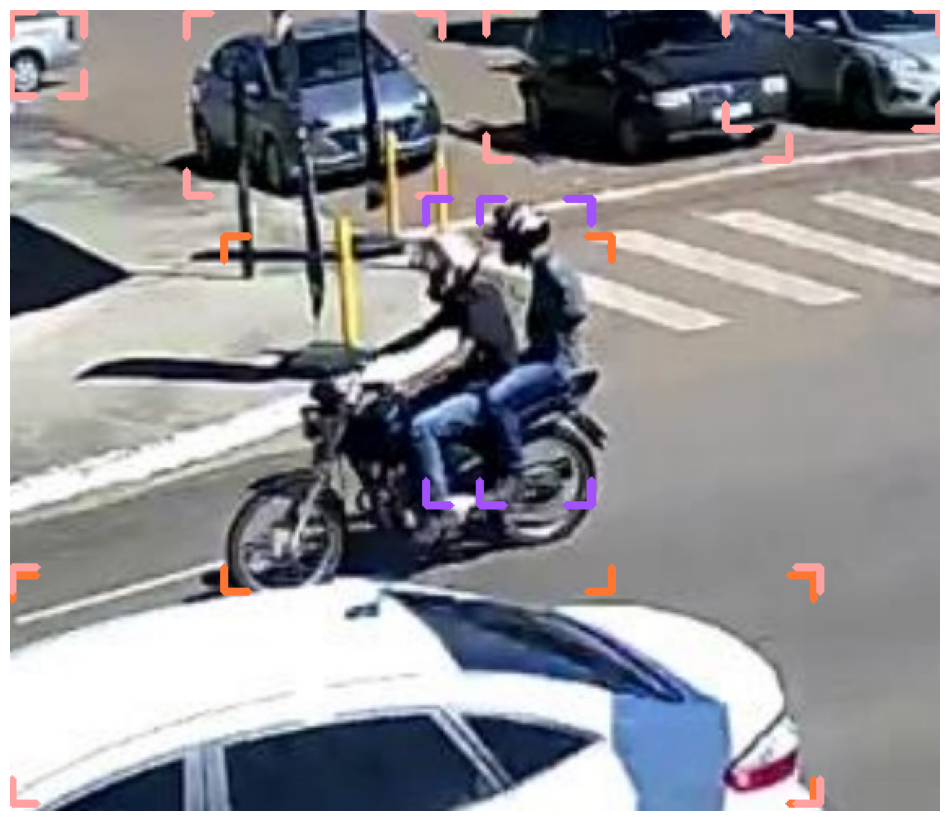

In [8]:
sv.plot_image(annotated_frame)

In [9]:
labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]
print(labels)
label_annotator = sv.LabelAnnotator(text_position=sv.Position.CENTER)
annotated_frame = label_annotator.annotate(
    scene=image.copy(),
    detections=detections,
    labels=labels
)

['car 0.88', 'car 0.85', 'car 0.85', 'motorcycle 0.68', 'person 0.58', 'truck 0.49', 'motorcycle 0.47', 'person 0.46', 'car 0.38', 'car 0.35']


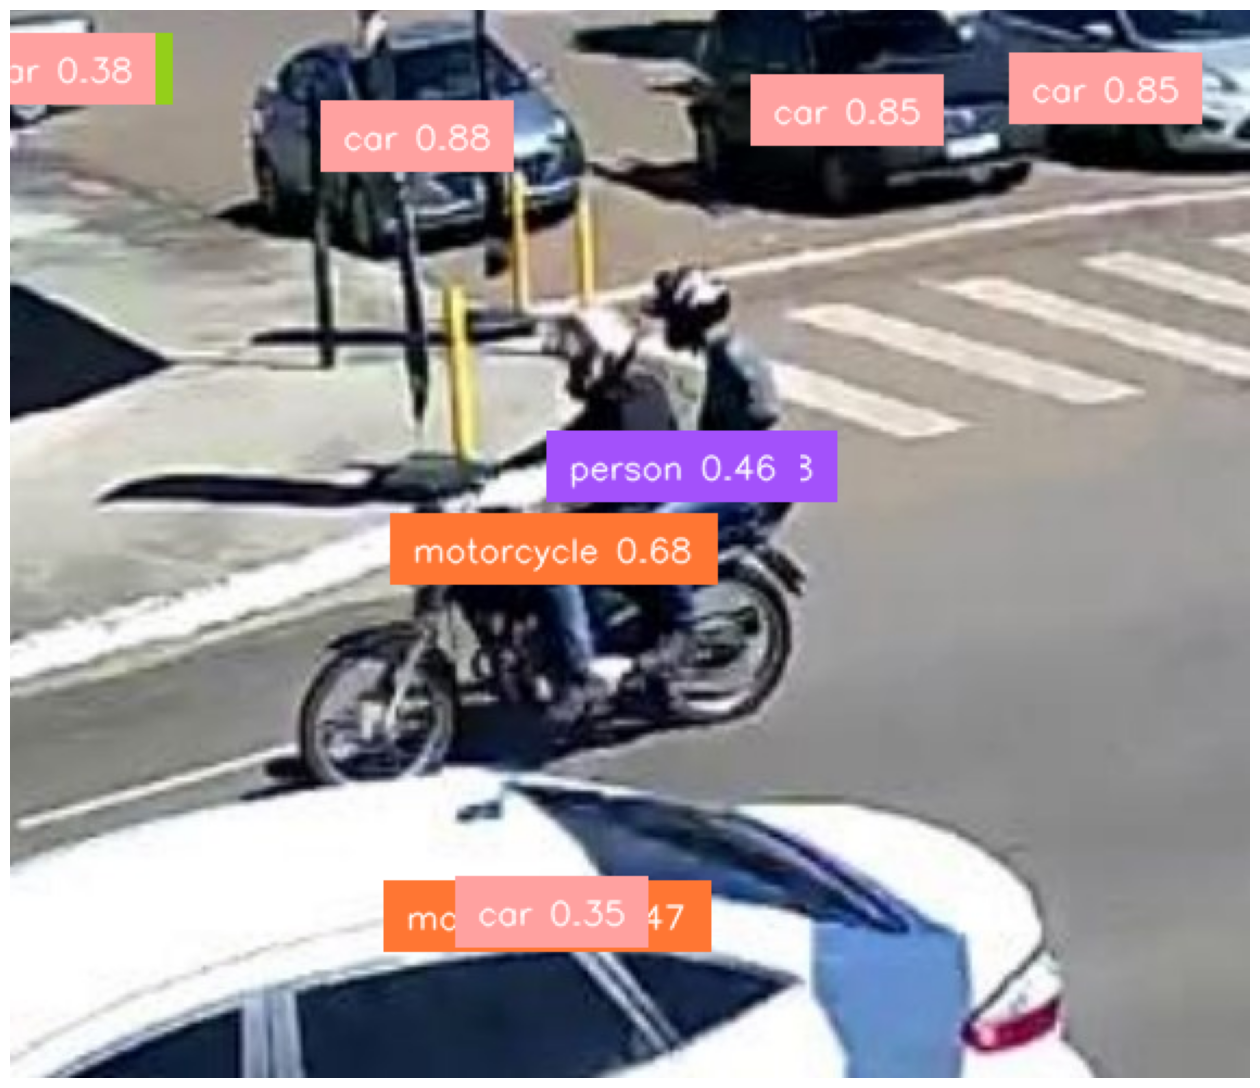

In [10]:
sv.plot_image(annotated_frame, (16, 16))

In [11]:
color_annotator = sv.ColorAnnotator()
annotated_frame = color_annotator.annotate(
    scene=image.copy(),
    detections=detections
)

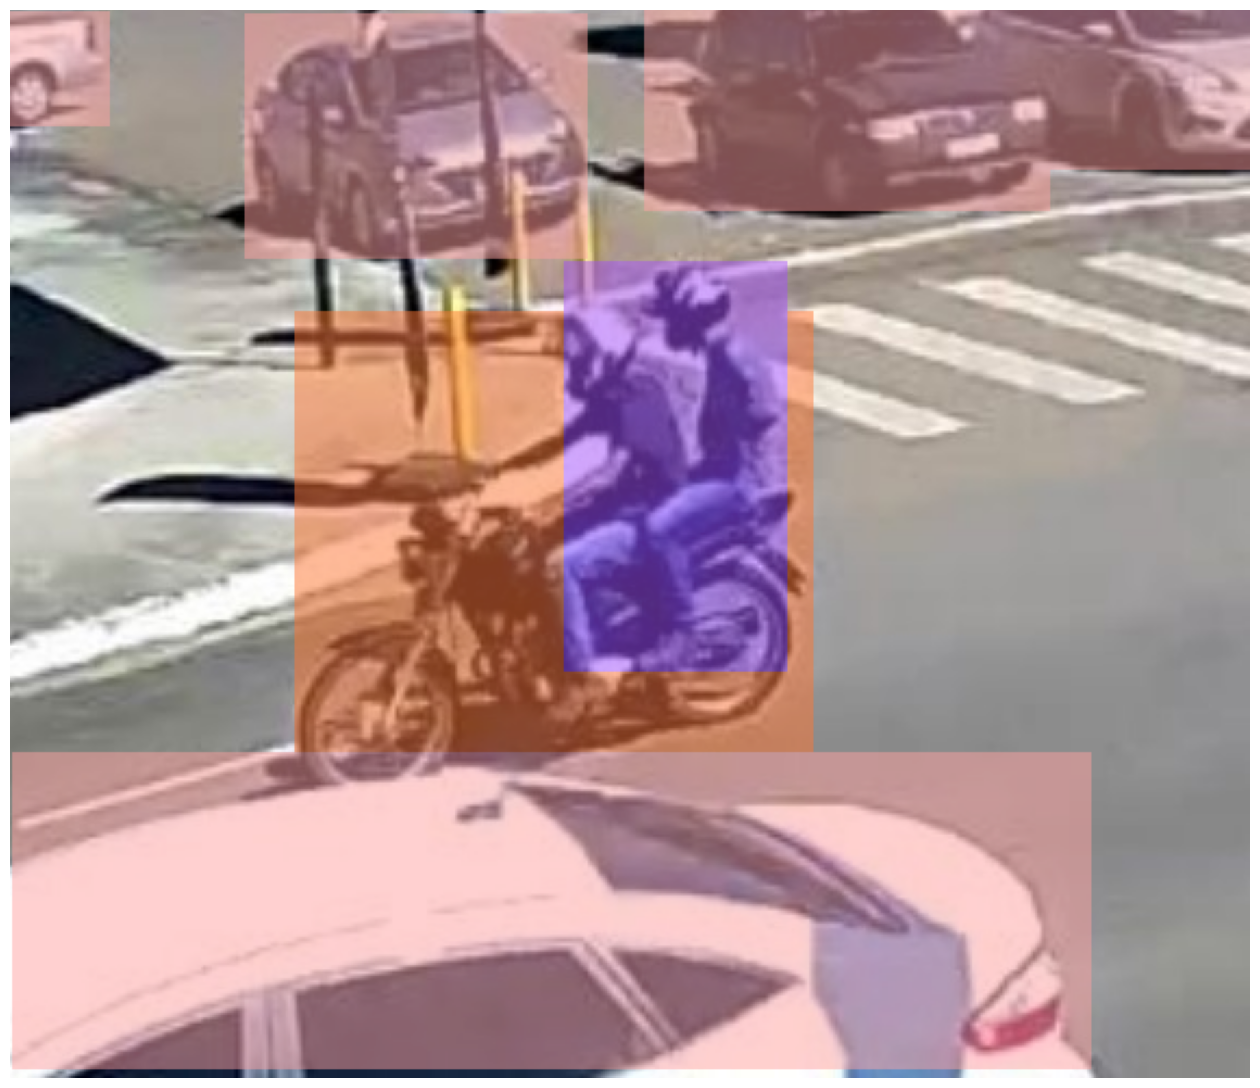

In [12]:
sv.plot_image(annotated_frame, (16, 16))

In [99]:
polygon_annotator = sv.PolygonAnnotator()
mask_annotator = sv.MaskAnnotator()
annotated_image = mask_annotator.annotate(image.copy(), detections=detections)
annotated_frame = polygon_annotator.annotate(
    annotated_image,
    detections=detections
)

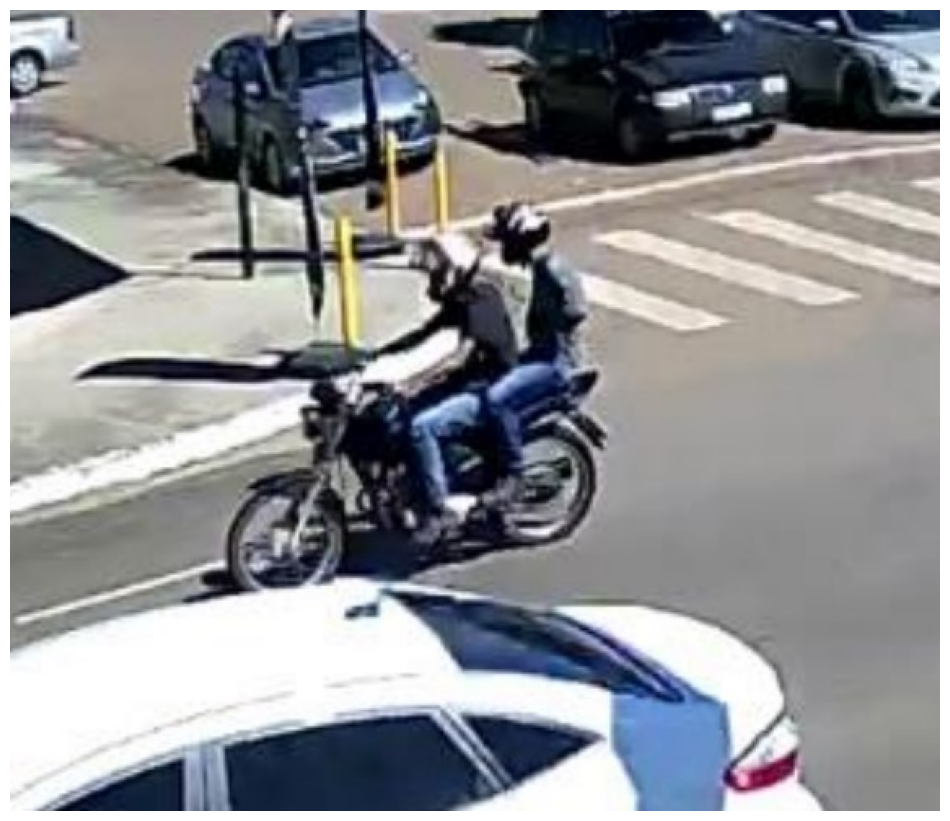

In [14]:
sv.plot_image(annotated_frame)

In [15]:
model = YOLO('yolov8s-pose.pt')
result_key = model(image_key)[0]
key_points = sv.KeyPoints.from_ultralytics(result_key)


0: 576x640 2 persons, 535.6ms
Speed: 2.6ms preprocess, 535.6ms inference, 2.2ms postprocess per image at shape (1, 3, 576, 640)


In [16]:
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.GREEN,
    radius=2
)
annotated_frame = vertex_annotator.annotate(
    scene=image_key.copy(),
    key_points=key_points
)

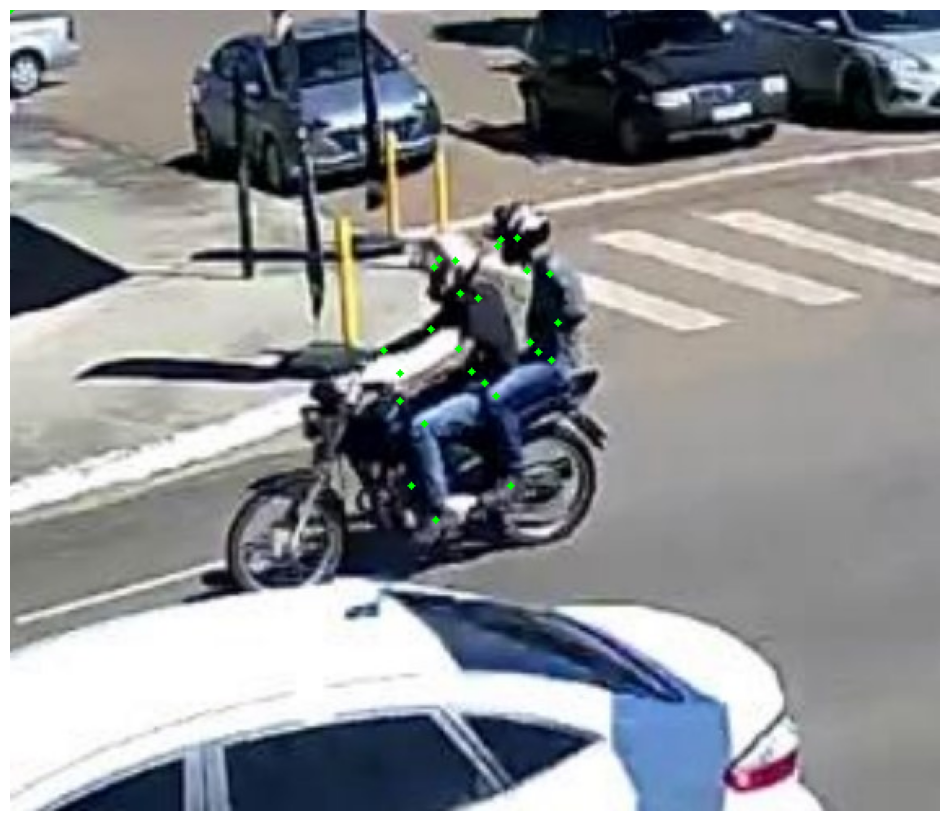

In [17]:
sv.plot_image(annotated_frame)

In [18]:
edge_annotator = sv.EdgeAnnotator(
    color=sv.Color.GREEN,
    thickness=2
)
annotated_frame = edge_annotator.annotate(
    scene=image_key.copy(),
    key_points=key_points
)
print(key_points)

KeyPoints(xy=array([[[     299.93,      145.83],
        [     301.62,      141.01],
        [          0,           0],
        [     311.85,      140.54],
        [          0,           0],
        [     331.37,      162.91],
        [     317.05,      160.37],
        [      336.6,      192.91],
        [          0,           0],
        [     319.05,      204.27],
        [          0,           0],
        [     332.28,      215.05],
        [     324.13,      210.55],
        [     298.26,      237.05],
        [          0,           0],
        [     307.26,      292.04],
        [          0,           0]],

       [[     260.68,      158.39],
        [     263.05,      153.93],
        [          0,           0],
        [     273.64,      154.24],
        [          0,           0],
        [     287.67,      177.03],
        [     276.25,      174.17],
        [     275.14,      208.58],
        [     258.65,      196.19],
        [     239.96,      223.51],
        [    

In [19]:
print(annotated_frame.shape)
annotated_frame[10:40,10:60,0]=0
annotated_frame[10:40,10:60,2]=0
print(annotated_frame[100,100,2])

(492, 571, 3)
142


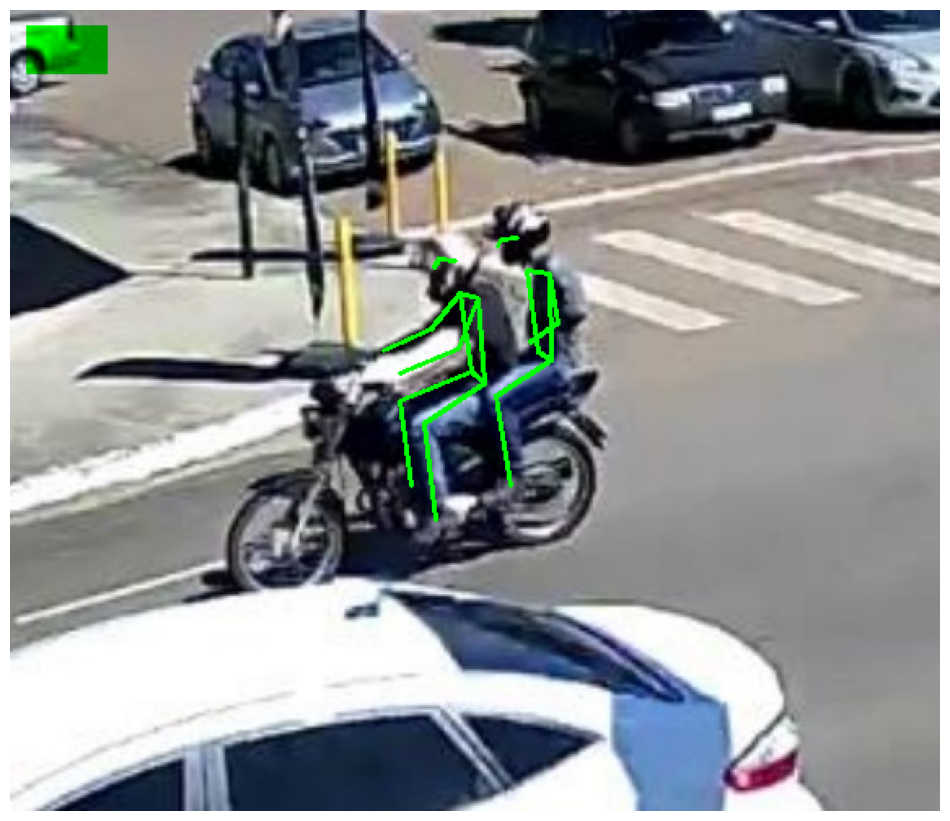

In [20]:
sv.plot_image(annotated_frame)

In [21]:
print(key_points)

KeyPoints(xy=array([[[     299.93,      145.83],
        [     301.62,      141.01],
        [          0,           0],
        [     311.85,      140.54],
        [          0,           0],
        [     331.37,      162.91],
        [     317.05,      160.37],
        [      336.6,      192.91],
        [          0,           0],
        [     319.05,      204.27],
        [          0,           0],
        [     332.28,      215.05],
        [     324.13,      210.55],
        [     298.26,      237.05],
        [          0,           0],
        [     307.26,      292.04],
        [          0,           0]],

       [[     260.68,      158.39],
        [     263.05,      153.93],
        [          0,           0],
        [     273.64,      154.24],
        [          0,           0],
        [     287.67,      177.03],
        [     276.25,      174.17],
        [     275.14,      208.58],
        [     258.65,      196.19],
        [     239.96,      223.51],
        [    




LABELS = [
    "nose", "left eye", "right eye", "left ear",
    "right ear", "left shoulder", "right shoulder", "left elbow",
    "right elbow", "left wrist", "right wrist", "left hip",
    "right hip", "left knee", "right knee", "left ankle",
    "right ankle"
]

In [44]:
print(key_points.xy.shape)
ff=(0,1)
print(ff)

(2, 17, 2)
(0, 1)


xy je 298
xy ce [     307.26      292.04]


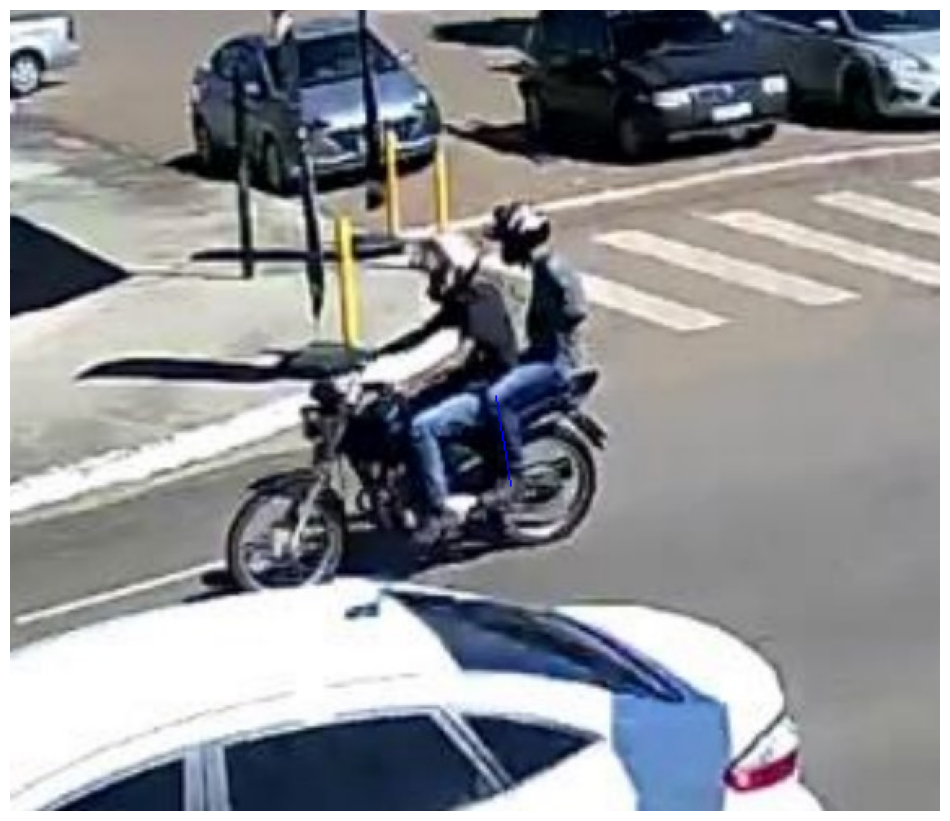

In [137]:
print(f"xy je {int(key_points.xy[0][13][0])}")
print(f"xy ce {key_points.xy[0][15]}")
cv2.line(annotated_frame, (int(key_points.xy[0][13][0]),int(key_points.xy[0][13][1])), (int(key_points.xy[0][15][0]),int(key_points.xy[0][15][1])), (255,0,0), 1) 
sv.plot_image(annotated_frame)

In [102]:
roi_pt1=(int(key_points.xy[0][13][0]),int(key_points.xy[0][13][1]))
roi_pt2=(int(key_points.xy[0][15][0]),int(key_points.xy[0][15][1]))
roi=annotated_frame[roi_pt1[1]:roi_pt2[1],roi_pt1[0]:roi_pt2[0],::]

In [106]:
print(roi_pt1[1],roi_pt2[1],roi_pt1[0],roi_pt2[0])

237 292 298 307


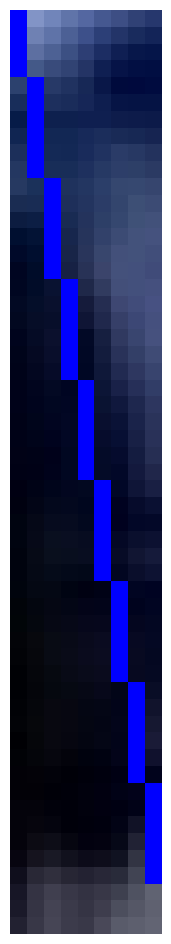

In [138]:
sv.plot_image(roi)

In [112]:
m=int((roi_pt2[1]-roi_pt1[1])/(roi_pt2[0]-roi_pt1[0]))

In [113]:
print(m)

6


In [114]:
b=roi_pt1[1]-6*roi_pt1[0]
print(b)

-1551


In [118]:
def fline(x): 
   y=6*x-1551
   return y

In [122]:
print(roi_pt1)
print(roi_pt2)

(298, 237)
(307, 292)


In [133]:
print(fline(307))
[ fline(i) for i in range(298,308) ]

291


[237, 243, 249, 255, 261, 267, 273, 279, 285, 291]

In [136]:
print(roi_pt2[0]-roi_pt1[0])
print(roi_pt2[1]-roi_pt1[1])

9
55
